# Visualización de la Evaluación Final de Métodos de Extracción
Este notebook consolida los resultados de todos los métodos evaluados y permite comparar visualmente su rendimiento final en los archivos de `extract-bench`, diferenciando entre imágenes de la carpeta `images` y texto seleccionable de la carpeta `pdfs`.

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurar estilo de Seaborn
sns.set_theme(style="whitegrid")

# Configurar fuente Palatino
plt.rcParams['font.family'] = 'serif'

### 1. Carga de Datos
Iteramos sobre todos los archivos `results.csv` en la carpeta `final_evaluations/` para crear un único DataFrame, diferenciando entre `images` (imágenes) y `pdfs` (texto seleccionable).

In [14]:
eval_dir = Path("final_evaluations")
all_data = []

for doc_type in ["images", "pdfs"]:
    type_dir = eval_dir / doc_type
    if not type_dir.exists():
        continue
    for method_dir in type_dir.iterdir():
        if method_dir.is_dir():
            csv_path = method_dir / "results.csv"
            if csv_path.exists():
                df = pd.read_csv(csv_path)
                df['Metodo'] = method_dir.name
                df['Tipo Documento'] = doc_type
                all_data.append(df)

if all_data:
    df_full = pd.concat(all_data, ignore_index=True)

    # Mapeo para convertir el nombre de la carpeta al nombre que usamos en la gráfica
    name_mapping = {
        'docling': 'Docling',
        'docling_header': 'Docling + header',
        'mineru': 'MinerU',
        'mineru_header': 'MinerU + header',
        'pymupdf': 'PyMuPDF4LLM',
        'pymupdf_header': 'PyMuPDF4LLM + header',
        'pymupdf_text': 'PyMuPDF',
        'pymupdf_text_header': 'PyMuPDF + header'
    }
    
    # Aplicar el mapeo a la columna Metodo
    df_full['Metodo'] = df_full['Metodo'].map(name_mapping).fillna(df_full['Metodo'])
    # Limpiar errores: Convertir "Error" a NaN y asegurar que la columna es numérica
    df_full['Puntuación'] = pd.to_numeric(df_full['Puntuación'], errors='coerce')
    df_full = df_full.dropna(subset=['Puntuación'])
    print(f"Cargados {len(df_full)} registros de evaluación en total.")
    
    # Separar por tipo de documento
    df_images = df_full[df_full['Tipo Documento'] == 'images'].copy()
    df_pdfs = df_full[df_full['Tipo Documento'] == 'pdfs'].copy()
    
    # Limpiar nombre de archivo: quitar extensión para mostrar solo el stem
    df_images['Archivo'] = df_images['Archivo'].str.replace(r'\.(pdf|image)$', '', regex=True)
    df_pdfs['Archivo'] = df_pdfs['Archivo'].str.replace(r'\.(pdf|image)$', '', regex=True)
    
    mean_scores_images = df_images.groupby(['Metodo', 'Tipo Documento'])['Puntuación'].mean().reset_index()
    mean_scores_pdfs = df_pdfs.groupby(['Metodo', 'Tipo Documento'])['Puntuación'].mean().reset_index()
    
    method_colors = {
        'Docling': '#4A90D9',
        'Docling + header': '#2C5F8E',
        'MinerU': '#63F89C',
        'MinerU + header': '#09C852',
        'PyMuPDF4LLM': '#F8D563',
        'PyMuPDF4LLM + header': '#F4BD0B',
        'PyMuPDF': '#FF745C',
        'PyMuPDF + header': '#D11F00'
    }
else:
    print("No se encontraron resultados.")
    df_images = pd.DataFrame()
    df_pdfs = pd.DataFrame()

Cargados 111 registros de evaluación en total.


### 2. Imágenes - Puntuación Media por Método

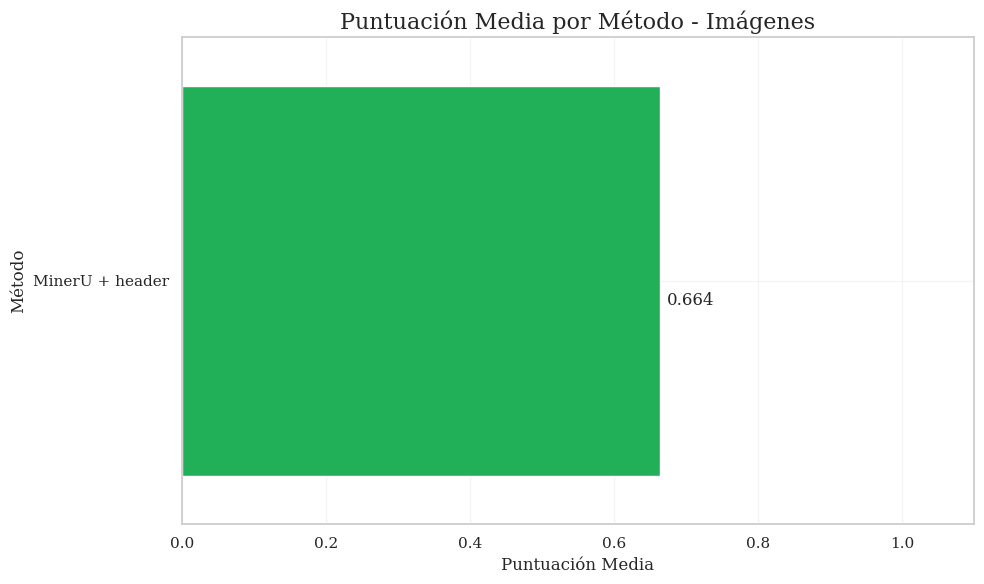

In [15]:
if not df_images.empty:
    plt.figure(figsize=(10, 6))
    
    colors = [method_colors[m] for m in mean_scores_images['Metodo'].unique()]
    
    ax = sns.barplot(data=mean_scores_images, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    plt.title('Puntuación Media por Método - Imágenes', fontsize=16)
    plt.xlabel('Puntuación Media', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    ax.grid(axis='both', alpha=0.2)
    
    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.01, p.get_y() + p.get_height()/2. + 0.05, '{:1.3f}'.format(width), ha="left")
    
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de imágenes para visualizar.")

### 3. Imágenes - Distribución de Puntuaciones (Boxplot)

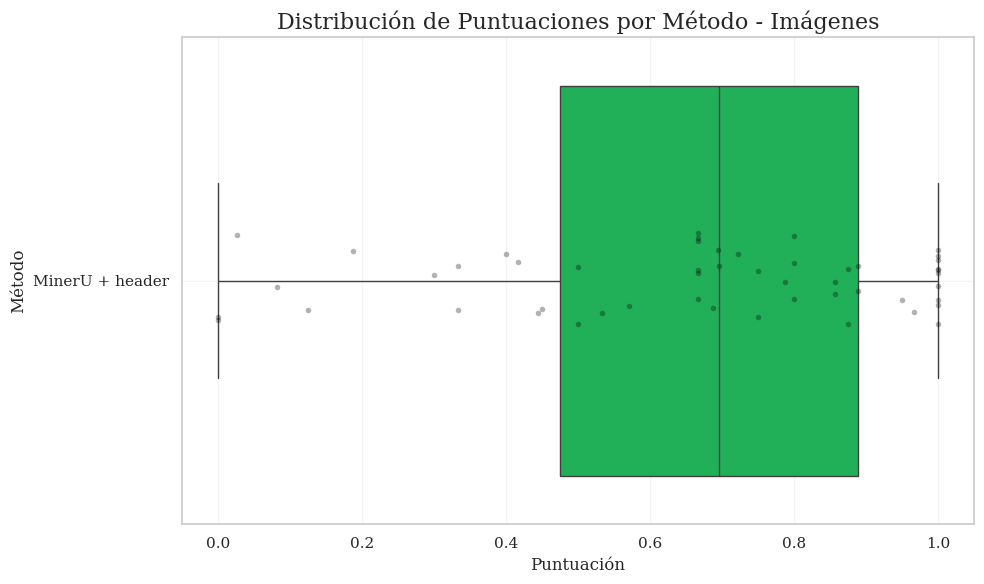

In [16]:
if not df_images.empty:
    plt.figure(figsize=(10, 6))
    
    colors = [method_colors[m] for m in df_images['Metodo'].unique()]
    
    sns.boxplot(data=df_images, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    sns.stripplot(data=df_images, x='Puntuación', y='Metodo', color='black', alpha=0.3, size=4, jitter=True)
    
    plt.grid(axis='both', alpha=0.2)
    
    plt.title('Distribución de Puntuaciones por Método - Imágenes', fontsize=16)
    plt.xlabel('Puntuación', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de imágenes para visualizar.")

### 4. PDFs (Texto Seleccionable) - Puntuación Media por Método

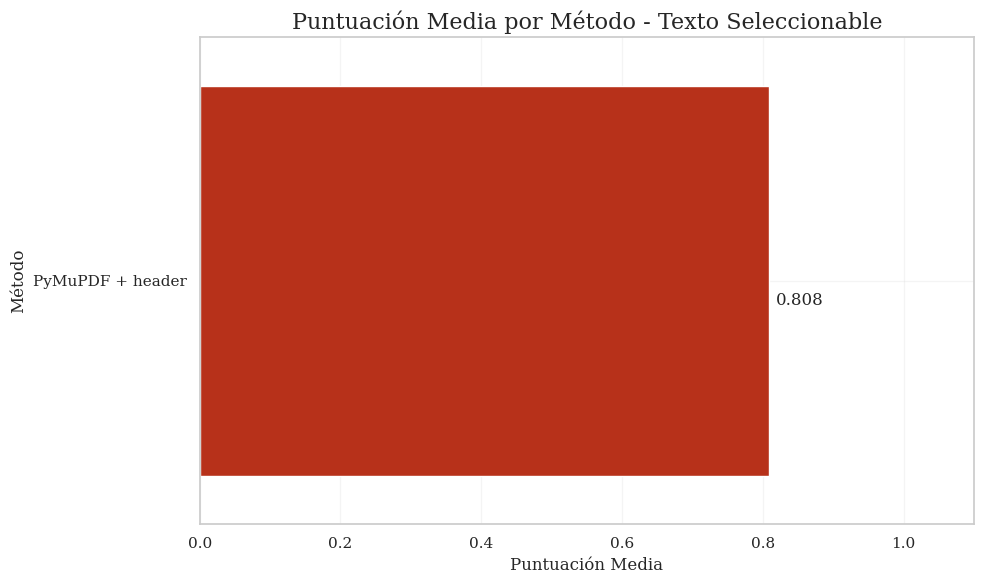

In [17]:
if not df_pdfs.empty:
    plt.figure(figsize=(10, 6))
    
    colors = [method_colors[m] for m in mean_scores_pdfs['Metodo'].unique()]
    
    ax = sns.barplot(data=mean_scores_pdfs, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    plt.title('Puntuación Media por Método - Texto Seleccionable', fontsize=16)
    plt.xlabel('Puntuación Media', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    ax.grid(axis='both', alpha=0.2)
    
    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.01, p.get_y() + p.get_height()/2. + 0.05, '{:1.3f}'.format(width), ha="left")
    
    plt.xlim(0, 1.1)
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de PDFs para visualizar.")

### 5. PDFs (Texto Seleccionable) - Distribución de Puntuaciones (Boxplot)
Muestra la dispersión: si las cajas son pequeñas significa que el modelo es muy consistente. Si hay muchos puntos fuera (outliers) o las cajas son largas, significa que a veces saca 1 y otras 0.

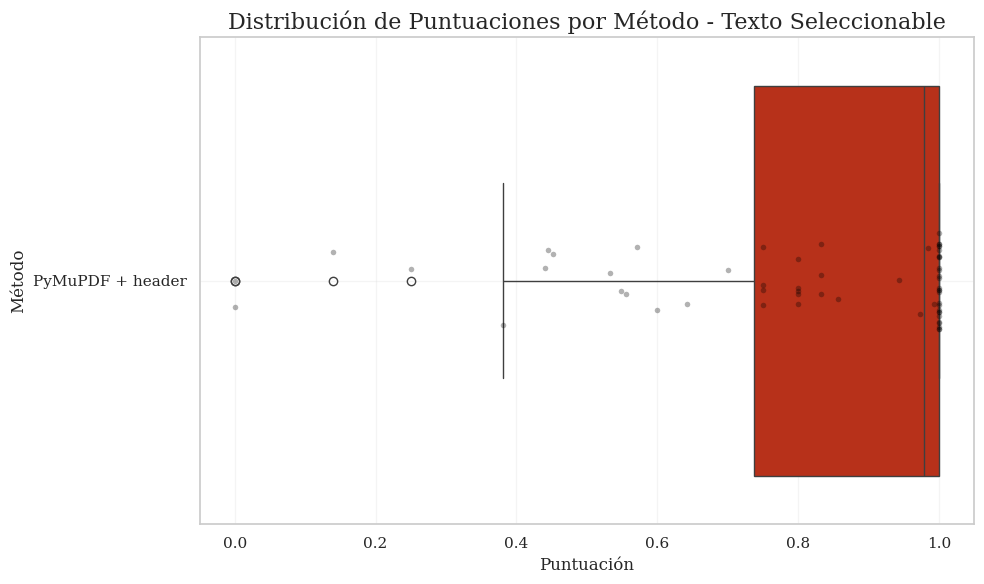

In [18]:
if not df_pdfs.empty:
    plt.figure(figsize=(10, 6))
    
    colors = [method_colors[m] for m in df_pdfs['Metodo'].unique()]
    
    sns.boxplot(data=df_pdfs, x='Puntuación', y='Metodo', hue='Metodo', palette=colors, dodge=False, legend=False)
    sns.stripplot(data=df_pdfs, x='Puntuación', y='Metodo', color='black', alpha=0.3, size=4, jitter=True)
    
    plt.grid(axis='both', alpha=0.2)
    
    plt.title('Distribución de Puntuaciones por Método - Texto Seleccionable', fontsize=16)
    plt.xlabel('Puntuación', fontsize=12)
    plt.ylabel('Método', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de PDFs para visualizar.")

### 6. Pipeline Final - Comparativa Imágenes vs Texto Seleccionable
Visualización conjunta de los resultados del pipeline final para ambos tipos de documento.

/tmp/ipykernel_828805/3359265425.py:36: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df_pipeline_final, x='Tipo Documento', y='Puntuación',


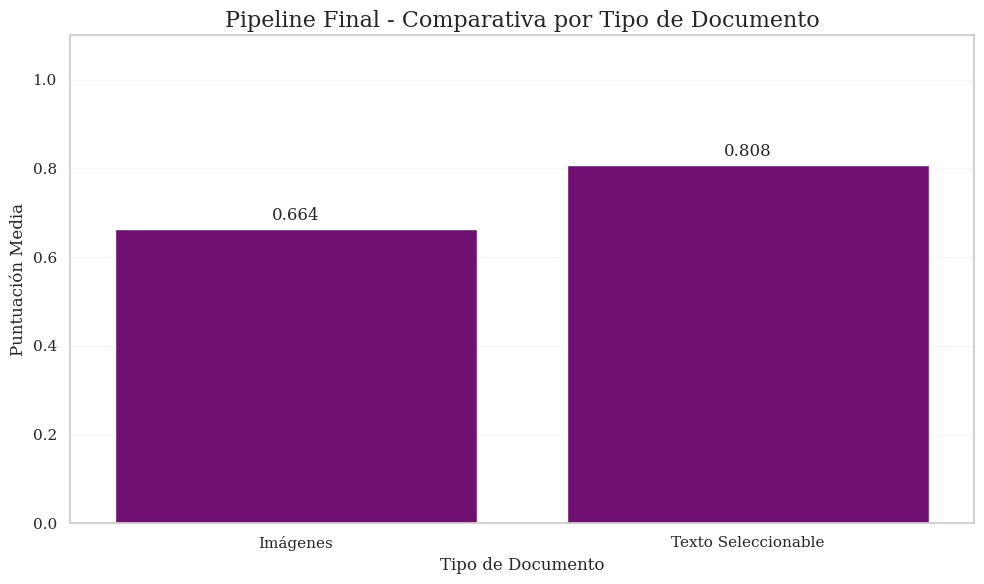

In [20]:
# Preparar datos para el gráfico combinado
pipeline_final_data = []

# Obtener resultados de MinerU + header para imágenes
if not df_images.empty:
    mineru_header_images = df_images[df_images['Metodo'] == 'MinerU + header'].copy()
    if not mineru_header_images.empty:
        avg_score_images = mineru_header_images['Puntuación'].mean()
        pipeline_final_data.append({
            'Tipo Documento': 'Imágenes',
            'Metodo': 'Pipeline final (MinerU + header)',
            'Puntuación': avg_score_images
        })

# Obtener resultados de PyMuPDF + header para PDFs
if not df_pdfs.empty:
    pymupdf_header_pdfs = df_pdfs[df_pdfs['Metodo'] == 'PyMuPDF + header'].copy()
    if not pymupdf_header_pdfs.empty:
        avg_score_pdfs = pymupdf_header_pdfs['Puntuación'].mean()
        pipeline_final_data.append({
            'Tipo Documento': 'Texto Seleccionable',
            'Metodo': 'Pipeline final (PyMuPDF + header)',
            'Puntuación': avg_score_pdfs
        })

# Crear DataFrame con los datos del pipeline final
if pipeline_final_data:
    df_pipeline_final = pd.DataFrame(pipeline_final_data)
    
    # Crear gráfico combinado
    plt.figure(figsize=(10, 6))
    
    # Color morado para el pipeline final
    purple_color = '#800080'
    
    ax = sns.barplot(data=df_pipeline_final, x='Tipo Documento', y='Puntuación', 
                     hue='Metodo', palette=[purple_color], dodge=False, legend=False)
    
    plt.title('Pipeline Final - Comparativa por Tipo de Documento', fontsize=16)
    plt.xlabel('Tipo de Documento', fontsize=12)
    plt.ylabel('Puntuación Media', fontsize=12)
    
    ax.grid(axis='y', alpha=0.2)
    
    # Añadir etiquetas con los valores
    for p in ax.patches:
        height = p.get_height()
        plt.text(p.get_x() + p.get_width()/2., height + 0.01,
                '{:1.3f}'.format(height), ha="center", va="bottom")
    
    plt.ylim(0, 1.1)
    plt.tight_layout()
    plt.savefig('graficas/pipeline_final.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No hay datos del pipeline final para visualizar.")